##### ARTI 560 - Computer Vision  
## Image Classification using Transfer Learning - Exercise

### Objective

In this exercise, you will:

1. Select another pretrained model (e.g., VGG16, MobileNetV2, or EfficientNet) and fine-tune it for CIFAR-10 classification.  
You'll find the pretrained models in [Tensorflow Keras Applications Module](https://www.tensorflow.org/api_docs/python/tf/keras/applications).

2. Before training, inspect the architecture using model.summary() and observe:
- Network depth
- Number of parameters
- Trainable vs Frozen layers

3. Then compare its performance with ResNet and the custom CNN.

### Questions:

- Which model achieved the highest accuracy?

  Fine-tuned ResNet50V2

- Which model trained faster?

  MobileNetV2 trains faster than ResNet50V2 because it uses depthwise separable convolutions and has fewer parameters.

- How might the architecture explain the differences?

  ResNet50V2: deep network with residual connections, easier optimization and strong features, higher accuracy but slower.

  MobileNetV2: inverted residual blocks+ depthwise separable convs, less representational power than big ResNets which sometimes a bit lower accuracy.

  Custom CNN: usually less depth, lower accuracy unless carefully engineered and trained longer.

In [1]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

# MobileNetV2 preprocessing
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

NUM_CLASSES = 10
IMG_SIZE = 96   # common choice; you can try 64 too to speed up

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug")

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
x = data_augmentation(x)
x = preprocess_input(x)

base = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False  # FREEZE

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES)(x)  # logits

mobilenet_model = keras.Model(inputs, outputs, name="MobileNetV2_CIFAR10")

# --- Inspect architecture ---
mobilenet_model.summary()
print("\nBackbone depth (layers):", len(base.layers))
print("Backbone params:", base.count_params())
print("Trainable params (full model):", mobilenet_model.trainable_variables.__len__())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Backbone depth (layers): 154
Backbone params: 2257984
Trainable params (full model): 2


In [2]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

t0 = time.time()
hist_mnet_frozen = mobilenet_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=1
)
t_frozen = time.time() - t0

test_loss_mnet_frozen, test_acc_mnet_frozen = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print("\nMobileNetV2 (frozen) test acc:", test_acc_mnet_frozen)
print("MobileNetV2 (frozen) train time (s):", t_frozen)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.6275 - loss: 1.1188 - val_accuracy: 0.8268 - val_loss: 0.5078
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7804 - loss: 0.6349 - val_accuracy: 0.8446 - val_loss: 0.4601
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7933 - loss: 0.6035 - val_accuracy: 0.8456 - val_loss: 0.4439

MobileNetV2 (frozen) test acc: 0.8414000272750854
MobileNetV2 (frozen) train time (s): 68.12337446212769


In [3]:
# Unfreeze last N layers
base.trainable = True
N = 30
for layer in base.layers[:-N]:
    layer.trainable = False

print("Trainable layers in backbone:", sum(l.trainable for l in base.layers), "/", len(base.layers))

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

t0 = time.time()
hist_mnet_ft = mobilenet_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=3,
    batch_size=64,
    verbose=1
)
t_ft = time.time() - t0

test_loss_mnet_ft, test_acc_mnet_ft = mobilenet_model.evaluate(x_test, y_test, verbose=0)
print("\nMobileNetV2 (fine-tuned) test acc:", test_acc_mnet_ft)
print("MobileNetV2 (fine-tuned) train time (s):", t_ft)

Trainable layers in backbone: 30 / 154
Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.7103 - loss: 0.9120 - val_accuracy: 0.8482 - val_loss: 0.4856
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.7987 - loss: 0.6052 - val_accuracy: 0.8648 - val_loss: 0.4244
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.8140 - loss: 0.5579 - val_accuracy: 0.8716 - val_loss: 0.3995

MobileNetV2 (fine-tuned) test acc: 0.8659999966621399
MobileNetV2 (fine-tuned) train time (s): 111.37047839164734


In [4]:
results = {
    "MobileNetV2 frozen": {"acc": test_acc_mnet_frozen, "time_s": t_frozen},
    "MobileNetV2 fine-tuned": {"acc": test_acc_mnet_ft, "time_s": t_ft}
}

for k,v in results.items():
    print(f"{k:22s} | acc={v['acc']:.4f} | time_s={v['time_s']}")

MobileNetV2 frozen     | acc=0.8414 | time_s=68.12337446212769
MobileNetV2 fine-tuned | acc=0.8660 | time_s=111.37047839164734


## ResNet50V2

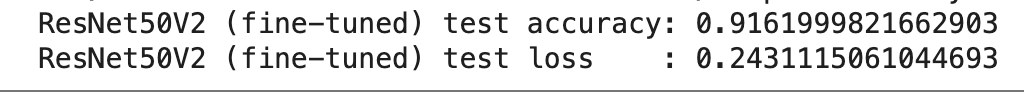

## CustomCNN first lab

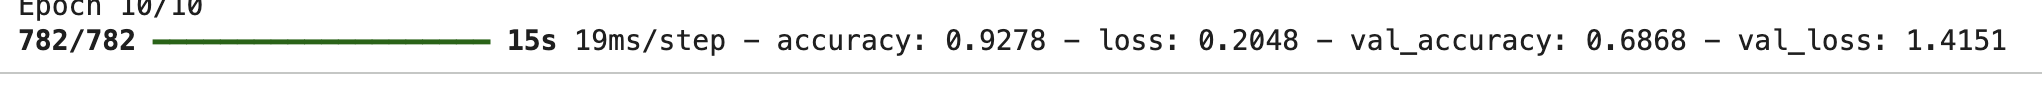